In [1]:
import os

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

import seaborn as sns
from ast import literal_eval

from typing import Dict, List, Optional, Tuple
from datetime import datetime, timedelta
import time

import glob
import json
import requests
from pprint import pprint

from concurrent.futures import ProcessPoolExecutor, as_completed
import logging

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import PartialDependenceDisplay

# from mlxtend.feature_selection import SequentialFeatureSelector as sfs

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

# import plotly.express as px

import time
import requests
import re

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

In [2]:
# !pip install --upgrade pip
# !pip install statsmodels

In [3]:
np.random.seed(42)

In [4]:
def calculate_pvalues(df, method='pearson'):
    n = df.shape[1]
    p_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                p_matrix[i, j] = 0
            else:
                if method == 'pearson':
                    corr, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
                elif method == 'spearman':
                    corr, p_value = spearmanr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
    return pd.DataFrame(p_matrix, index=df.columns, columns=df.columns)

def annotate_with_pvalues(corr_matrix, p_matrix):
    annot_matrix = np.empty_like(corr_matrix, dtype=object)
    n = corr_matrix.shape[0]
    
    for i in range(n):
        for j in range(n):
            if i == j:
                annot_matrix[i, j] = '1.00'
            elif mask[i, j]: 
                annot_matrix[i, j] = ''
            else:
                corr_val = corr_matrix.iloc[i, j]
                p_val = p_matrix.iloc[i, j]
                
                stars = ''
                if p_val < 0.01:
                    stars = '***'
                elif p_val < 0.05:
                    stars = '**'
                elif p_val < 0.1:
                    stars = '*'
                
                annot_matrix[i, j] = f'{corr_val:.2f}{stars}'
    
    return annot_matrix

def plot_corr_matrix(corr_matrix, mask, annotations, title='Correlation with p-values'):
    plt.figure(figsize=(12, 10))
    heatmap = sns.heatmap(corr_matrix,
                mask=mask,
                annot=annotations,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='', 
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 9})

    plt.title(title, fontsize=16, pad=20)

    legend_text = '\n'.join([
        '*** p < 0.01',
        '** p < 0.05', 
        '* p < 0.1',
    #     'Без звездочек: p ≥ 0.05'
    ])
    plt.figtext(0.72, 0.92, legend_text, fontsize=10, 
               bbox=dict(boxstyle="round, pad=0.5", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()


def parse_industry_file_with_expanded_codes(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    
    industry_blocks = re.split(r'\n\s*\n', content.strip())
    
    data = []
    
    for block in industry_blocks:
        lines = block.strip().split('\n')
        
        if len(lines) < 2:
            continue
        
        first_line = lines[0].strip()
        match = re.match(r'(\d+)\s+(\w+)\s+(.+)', first_line)
        
        if match:
            industry_num = int(match.group(1))
            industry_code = match.group(2)
            industry_name = match.group(3).strip()
            
            # Обрабатываем диапазоны кодов
            for line in lines[1:]:
                line = line.strip()
                if line and re.match(r'\d{4}-\d{4}', line):
                    start, end = map(int, line.split('-'))
                    
                    # Создаем отдельную запись для каждого кода в диапазоне
                    for code in range(start, end + 1):
                        data.append({
                            'industry_number': industry_num,
                            'industry_code': industry_code,
                            'industry_name': industry_name,
                            'sic_code': code
                        })
    
    return pd.DataFrame(data)

In [5]:
def category_plot(col, depvar, data,
                  order=None, ylabel=None, xlabel=None,
                  path=None, ax=None, verbose=False):
    sns.set(style="ticks")
    nobs = data[col].value_counts()
    medians = data.groupby(col,observed=True)[depvar].median()
    means = data.groupby(col,observed=True)[depvar].mean()
    if verbose:
        print(f"{means=}")
        print(f"p-value={f_oneway(*[data.loc[data[col]==c,depvar] for c in nobs.index.to_list()]).pvalue}")
    if not order:
        order = list(nobs.index.sort_values())
        box = sns.boxenplot(data=data, x=col, y=depvar, order=order, width=0.8,
                      linewidth=0.8, linecolor="0.2", ax=ax);
        box.set(xlabel=xlabel if xlabel else None, ylabel=ylabel if ylabel else "Llama Polarity");
    for i, c in enumerate(order):
        box.text(i, medians[c]-0.01, "n="+str(nobs[c]),
                  horizontalalignment='center',
                  fontdict={'fontsize':9});
        box.text(i, means[c], "x",
                  horizontalalignment='center',
                  fontdict={'fontsize':8, 'color':'red'});
    if path:
        path = join(tables_path, path)
        plt.savefig(path, bbox_inches='tight');
    return box

## Target

- 10-K CAR[0,1] The cumulative market-adjusted return for the firm in the [0,1] trading window surrounding the current-
year 10-K filing date

## Control variables


- BTM Book to market ratio calculated as the firm’s book value of common equity at the end of quarter or year
divided by MVE

- INSTOWN ML 10-K CAR[0,1] The percentage of shares of the firm held by institutional investors

- MVE Market value of equity for the firm in the current quarter or year calculated as the firm’s stock price
multiplied by the number of shares outstanding at the end of the quarter or year

- NASDAQ An indicator variable equal to the one if the firm is traded on the NASDAQ and equal to zero otherwise

- PRE_FFALPHA It is the Fama–French alpha based on a regression of their three-factor model using trading days [−252,−6]
relative to the conference call or 10-K filing date. At least 60 observations of daily returns must be
available to be included in the sample.

- TURNOVER The number of shares traded for the firm in the trading days [−252,−6] relative to the conference call or
10-K filing date divided by the firm’s shares outstanding at the conference call or 10-K filing date

## Data

### Reports

In [6]:
file_path = 'Siccodes12.txt'
df_expanded = parse_industry_file_with_expanded_codes(file_path)
df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)
# df_expanded

In [7]:
df_expanded['industry_name'].unique()

array(['Consumer Nondurables -- Food, Tobacco, Textiles, Apparel, Leather, Toys',
       'Consumer Durables -- Cars, TVs, Furniture, Household Appliances',
       'Manufacturing -- Machinery, Trucks, Planes, Off Furn, Paper, Com Printing',
       'Oil, Gas, and Coal Extraction and Products',
       'Chemicals and Allied Products',
       'Business Equipment -- Computers, Software, and Electronic Equipment',
       'Telephone and Television Transmission', 'Utilities',
       'Wholesale, Retail, and Some Services (Laundries, Repair Shops)',
       'Healthcare, Medical Equipment, and Drugs', 'Finance'],
      dtype=object)

### Replication data from Frankel 

In [8]:
df = pd.read_sas('finaldata_10k.sas7bdat')
df.tail()

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01
75357,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1079.670621,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893
75358,b'317264',2018-03-31,7.49,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.62410,2.325150,58762972.0,55107.0,1066.343151,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591
75359,b'317264',2019-03-31,6.42,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.17856,2.508930,40707109.0,55167.0,737.888756,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175
75360,b'318728',2017-12-31,51.71,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.39863,0.891005,334320819.0,142348.0,2348.616201,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623
75361,b'318728',2018-12-31,39.83,197.100,8276.000,0.722051,55804.0,16496.0,2019-02-27,b'1527469_0001527469-19-000007',7850.49300,1.054201,338861633.0,164849.0,2055.588041,-0.000151,0.0,0.006164,0.007526,0.013676,-0.290089,0.078818,0.049895,0.224715,0.001628,-0.119722,-0.002462,2019.0,8.968332,-1.054262


In [9]:
df['date_filed'] = df['date_filed'].astype(str)
df['ACC_NUM'] = df['filename'].astype(str).str.split('_').str[1].str.replace("'", "")
df['CIK'] = df['filename'].astype(str).str.split('_').str[0].str.replace("b'", "")
df['FILING_DATE'] = df['date_filed'].astype(str).str.replace('-', '')

cols_to_winsorize = ['tone', 'tone_pos', 'tone_neg', 'tone_harvard', 'tone_posharvard', 'tone_negharvard', 'mve', 'factorpred_car01']

for column in cols_to_winsorize:
    df[column] = winsorize(df[column], limits=[0.01, 0.01])

df['turnover'] = df['turnover'] / 1000

In [10]:
df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,0.550284,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1.181769,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,0.657306,0.000424,0.0,0.025747,0.005877,0.003495,0.287129,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,0.939015,-0.000434,0.0,0.014496,0.005442,0.003495,0.287129,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,0.958469,-0.002255,0.0,-0.027259,0.004120,0.003495,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.886750,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.624100,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628
75359,b'317264',2019-03-31,6.420000,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.178560,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530
75360,b'318728',2017-12-31,51.710000,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.398630,0.891005,334320819.0,142348.0,2.348616,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623,0001527469-18-000011,1527469,20180226


## Sentiments from Llama 3.1
### missing

In [11]:
missing = pd.read_csv('/home/jovyan/datavol-2/missing_item7.tsv.gz', sep='\t')
missing['ACC_NUM'] = missing['name'].astype(str).str.split('_').str[-1]
missing['CIK'] = missing['name'].astype(str).str.split('_').str[-2]
missing['FILING_DATE'] = missing['name'].astype(str).str.split('_').str[0]
missing = missing[['CIK', 'FILING_DATE', 'ACC_NUM']]
missing = missing.reset_index()
# missing

In [12]:
general_sent = pd.read_csv('sentiments_missing/final_results_general.csv')
revenue_sent = pd.read_csv('sentiments_missing/final_results_revenue.csv')
profit_sent = pd.read_csv('sentiments_missing/final_results_profit.csv')

strategic_risk_sent = pd.read_csv('sentiments_missing/final_results_strategic_risk.csv')
operational_risk_sent = pd.read_csv('sentiments_missing/final_results_operational_risk.csv')
financial_risk_sent = pd.read_csv('sentiments_missing/final_results_financial_risk.csv')
reputational_risk_sent = pd.read_csv('sentiments_missing/final_results_reputational_risk.csv')
compliance_risk_sent = pd.read_csv('sentiments_missing/final_results_compliance_risk.csv')

In [13]:
general_sent = general_sent.rename(columns={col: col+'_general' for col in general_sent.columns if col != 'index'})
revenue_sent = revenue_sent.rename(columns={col: col+'_revenue' for col in revenue_sent.columns if col != 'index'})
profit_sent = profit_sent.rename(columns={col: col+'_profit' for col in profit_sent.columns if col != 'index'})

strategic_risk_sent = strategic_risk_sent.rename(columns={col: col+'_strategic_risk' for col in strategic_risk_sent.columns if col != 'index'})
operational_risk_sent = operational_risk_sent.rename(columns={col: col+'_operational_risk' for col in operational_risk_sent.columns if col != 'index'})
financial_risk_sent = financial_risk_sent.rename(columns={col: col+'_financial_risk' for col in financial_risk_sent.columns if col != 'index'})

reputational_risk_sent = reputational_risk_sent.rename(columns={col: col+'_reputation_risk' for col in reputational_risk_sent.columns if col != 'index'})
compliance_risk_sent = compliance_risk_sent.rename(columns={col: col+'_compliance_risk' for col in compliance_risk_sent.columns if col != 'index'})

sent = general_sent.merge(revenue_sent, on='index')\
.merge(profit_sent, on='index')\
.merge(strategic_risk_sent, on='index')\
.merge(operational_risk_sent, on='index')\
.merge(financial_risk_sent, on='index')\
.merge(reputational_risk_sent, on='index')\
.merge(compliance_risk_sent, on='index')

In [14]:
sent.shape

(13536, 25)

In [15]:
sent_missing = missing.merge(sent, on='index')
sent_missing = sent_missing.drop('index', axis=1)
# sent_missing.shape

In [16]:
# 1996 -- 2023 (without missing reports)
all_sent = pd.read_csv('all_sentiment.csv')
all_sent = all_sent.drop('Unnamed: 0', axis=1)
all_sent['CIK'] = all_sent['CIK'].astype(str)
all_sent['FILING_DATE'] = all_sent['FILING_DATE'].astype(str)

In [17]:
all_sent

,CIK,FILING_DATE,ACC_NUM,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk
0,1750,20020826,0000912057-02-033450,0.058687,0.195582,-0.136895,0.136032,0.187103,-0.051071,0.197464,0.101707,0.095757,0.098328,0.313736,-0.215408,0.062782,0.309700,-0.246918,0.124844,0.280563,-0.155720,0.055691,0.270439,-0.214748,0.111652,0.233459,-0.121807
1,1750,20030818,0001047469-03-028005,0.251242,0.105926,0.145316,0.153076,0.123199,0.029877,0.200882,0.121155,0.079727,0.186245,0.246414,-0.060169,0.204582,0.150684,0.053898,0.252907,0.108986,0.143921,0.129883,0.237461,-0.107578,0.176495,0.195606,-0.019112
2,1750,20040722,0001047469-04-023905,0.177849,0.112457,0.065392,0.183945,0.080505,0.103439,0.200584,0.090813,0.109772,0.125092,0.302937,-0.177845,0.087914,0.300018,-0.212105,0.124878,0.294327,-0.169449,0.074173,0.278572,-0.204399,0.124195,0.244942,-0.120747
3,1750,20050722,0001104659-05-033688,0.241506,0.040220,0.201285,0.165558,0.071747,0.093811,0.178215,0.073090,0.105125,0.140617,0.284660,-0.144043,0.105381,0.273033,-0.167652,0.178501,0.208374,-0.029873,0.087654,0.247326,-0.159672,0.129677,0.219227,-0.089550
4,1750,20060717,0001104659-06-047248,0.261249,0.072720,0.188529,0.212341,0.093018,0.119324,0.181458,0.099716,0.081741,0.163521,0.229065,-0.065544,0.125561,0.220493,-0.094933,0.143944,0.156502,-0.012558,0.115681,0.192966,-0.077286,0.180267,0.161652,0.018616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89375,1948455,20230919,0001213900-23-077437,0.093828,0.251150,-0.157322,0.215485,0.081482,0.134003,0.238468,0.098946,0.139523,0.191422,0.234772,-0.043350,0.187447,0.217674,-0.030228,0.267273,0.106071,0.161201,0.141853,0.247536,-0.105682,0.250092,0.174759,0.075333
89376,1951276,20230928,0000950170-23-050475,0.302252,0.061148,0.241104,0.204483,0.205444,-0.000961,0.143036,0.117920,0.025116,0.268799,0.195885,0.072914,0.290550,0.115242,0.175308,0.223862,0.053146,0.170715,0.184246,0.182049,0.002197,0.219688,0.150436,0.069252
89377,1967306,20231229,0001558370-23-020031,0.335243,0.054060,0.281183,0.246277,0.160919,0.085358,0.187378,0.089752,0.097626,0.227222,0.203651,0.023571,0.246239,0.138077,0.108162,0.246307,0.075447,0.170860,0.138008,0.212601,-0.074593,0.248207,0.153183,0.095024
89378,1967649,20231221,0001967649-23-000025,0.315893,0.074120,0.241774,0.192932,0.046753,0.146179,0.187988,0.106331,0.081657,0.170586,0.264442,-0.093857,0.109367,0.289715,-0.180347,0.194183,0.197166,-0.002983,0.119400,0.272125,-0.152725,0.218292,0.220474,-0.002182


In [18]:
full_sent = pd.concat([all_sent, sent_missing], axis=0, ignore_index=True)
full_sent.shape, full_sent.drop_duplicates(['CIK', 'FILING_DATE', 'ACC_NUM']).shape, full_sent.drop_duplicates().shape

((102916, 27), (98254, 27), (102913, 27))

In [19]:
full_sent = full_sent.drop_duplicates(['CIK', 'FILING_DATE', 'ACC_NUM'], keep='first')

In [20]:
full_sent

,CIK,FILING_DATE,ACC_NUM,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk
0,1750,20020826,0000912057-02-033450,0.058687,0.195582,-0.136895,0.136032,0.187103,-0.051071,0.197464,0.101707,0.095757,0.098328,0.313736,-0.215408,0.062782,0.309700,-0.246918,0.124844,0.280563,-0.155720,0.055691,0.270439,-0.214748,0.111652,0.233459,-0.121807
1,1750,20030818,0001047469-03-028005,0.251242,0.105926,0.145316,0.153076,0.123199,0.029877,0.200882,0.121155,0.079727,0.186245,0.246414,-0.060169,0.204582,0.150684,0.053898,0.252907,0.108986,0.143921,0.129883,0.237461,-0.107578,0.176495,0.195606,-0.019112
2,1750,20040722,0001047469-04-023905,0.177849,0.112457,0.065392,0.183945,0.080505,0.103439,0.200584,0.090813,0.109772,0.125092,0.302937,-0.177845,0.087914,0.300018,-0.212105,0.124878,0.294327,-0.169449,0.074173,0.278572,-0.204399,0.124195,0.244942,-0.120747
3,1750,20050722,0001104659-05-033688,0.241506,0.040220,0.201285,0.165558,0.071747,0.093811,0.178215,0.073090,0.105125,0.140617,0.284660,-0.144043,0.105381,0.273033,-0.167652,0.178501,0.208374,-0.029873,0.087654,0.247326,-0.159672,0.129677,0.219227,-0.089550
4,1750,20060717,0001104659-06-047248,0.261249,0.072720,0.188529,0.212341,0.093018,0.119324,0.181458,0.099716,0.081741,0.163521,0.229065,-0.065544,0.125561,0.220493,-0.094933,0.143944,0.156502,-0.012558,0.115681,0.192966,-0.077286,0.180267,0.161652,0.018616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102908,1021010,20040324,0000950129-04-001501,0.145679,0.142349,0.003329,0.146133,0.112854,0.033279,0.196159,0.111633,0.084526,0.201675,0.223671,-0.021996,0.192635,0.158768,0.033867,0.238380,0.107063,0.131317,0.153629,0.225739,-0.072109,0.176094,0.193947,-0.017853
102909,945436,20150302,0000945436-15-000049,0.103672,0.156784,-0.053112,0.226448,0.198868,0.027580,0.107452,0.076500,0.030952,0.070511,0.295334,-0.224823,0.071213,0.279854,-0.208641,0.068901,0.287476,-0.218575,0.044399,0.284912,-0.240513,0.101967,0.236046,-0.134079
102911,743316,20160812,0000743316-16-000081,0.200651,0.082823,0.117828,0.111885,0.108109,0.003777,0.133003,0.104523,0.028481,0.157478,0.245491,-0.088013,0.151997,0.205494,-0.053497,0.232895,0.105324,0.127571,0.101551,0.233238,-0.131687,0.187366,0.225014,-0.037647
102912,1040719,20150226,0001040719-15-000002,0.079987,0.135731,-0.055744,0.168121,0.195557,-0.027435,0.193169,0.089539,0.103630,0.096313,0.334496,-0.238182,0.030602,0.386337,-0.355736,0.064461,0.293640,-0.229179,0.035843,0.366177,-0.330334,0.024361,0.355228,-0.330868


In [21]:
df['CIK'] = df['CIK'].astype(str)
df['FILING_DATE'] = df['FILING_DATE'].astype(str)
df['ACC_NUM'] = df['ACC_NUM'].astype(str)
df.shape

(75362, 33)

In [22]:
sent_df = df.merge(full_sent, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
sent_df.shape

(75362, 57)

In [23]:
sent_df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,0.550284,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1.181769,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,0.657306,0.000424,0.0,0.025747,0.005877,0.003495,0.287129,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,0.939015,-0.000434,0.0,0.014496,0.005442,0.003495,0.287129,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,0.958469,-0.002255,0.0,-0.027259,0.004120,0.003495,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.886750,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614,0.095707,0.200253,-0.104546,0.206909,0.194901,0.012009,0.197632,0.083611,0.114021,0.155170,0.225895,-0.070724,0.157509,0.195686,-0.038177,0.136917,0.213871,-0.076954,0.119865,0.224174,-0.104309,0.179798,0.183304,-0.003506
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.624100,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.0225

In [24]:
lm_data = pd.read_csv('Loughran-McDonald_10X_Summaries_1993-2023.csv',
                          usecols=['CIK', 'FILING_DATE', 'ACC_NUM', 'SIC'])
lm_data['FILING_DATE'].min()

19930813

In [25]:
lm_data['CIK'] = lm_data['CIK'].astype(str)
lm_data['FILING_DATE'] = lm_data['FILING_DATE'].astype(str)

In [26]:
# sent_df_ = sent_df.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
sent_df = sent_df.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
sent_df['SIC'] = sent_df['SIC'].astype(str)

In [27]:
file_path = 'Siccodes12.txt'
df_expanded = parse_industry_file_with_expanded_codes(file_path)
df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)

In [28]:
df_expanded.head()

,industry_number,industry_code,industry_name,sic_code
0,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",100
1,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",101
2,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",102
3,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",103
4,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",104


In [125]:
# sent_df = sent_df.merge(df_expanded, left_on='SIC', right_on='sic_code', how='left')

# sent_df['industry_code'] = sent_df['industry_code'].fillna('Other')
# sent_df['industry_name'] = sent_df['industry_name'].fillna('Other')

In [30]:
# sent_df[['industry_name']].info()

In [65]:
# df_expanded['industry_name'].value_counts().sort_index()

In [66]:
# sent_df['industry_name'].value_counts().sort_index()

Business Equipment -- Computers, Software, and Electronic Equipment          13168
Chemicals and Allied Products                                                 1707
Consumer Durables -- Cars, TVs, Furniture, Household Appliances               1833
Consumer Nondurables -- Food, Tobacco, Textiles, Apparel, Leather, Toys       3422
Finance                                                                      14187
Healthcare, Medical Equipment, and Drugs                                      8732
Manufacturing -- Machinery, Trucks, Planes, Off Furn, Paper, Com Printing     7072
Oil, Gas, and Coal Extraction and Products                                    3233
Other                                                                        10336
Telephone and Television Transmission                                         1917
Utilities                                                                     2403
Wholesale, Retail, and Some Services (Laundries, Repair Shops)                7352
Name

In [67]:
sent_df.to_csv("frankel_llama_sentiments_full_sample.tsv.gz", sep='\t', compression='gzip', index=False)

In [31]:
missing['ACC_NUM'].nunique(), missing.shape[0]

(13587, 13587)

In [32]:
sent_df[~sent_df['ACC_NUM'].isin(missing['ACC_NUM'])].shape

(61774, 58)

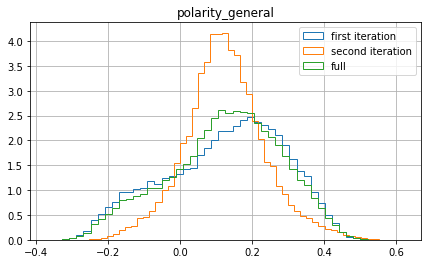

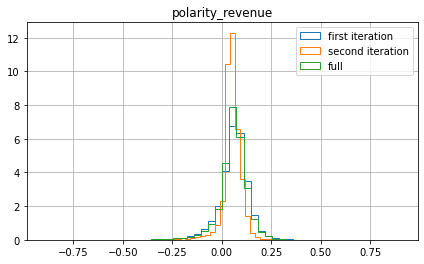

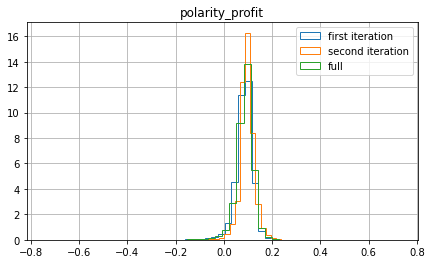

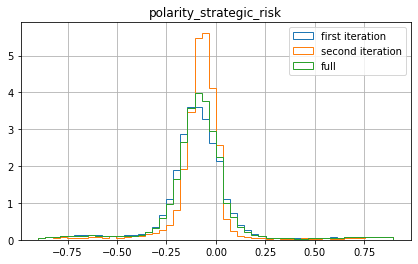

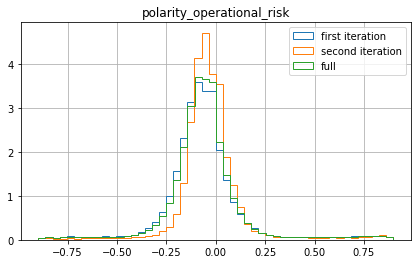

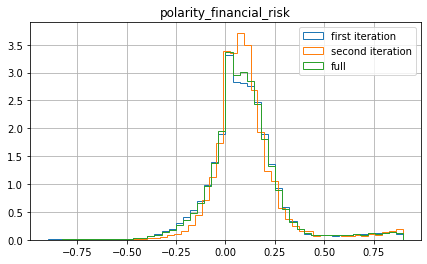

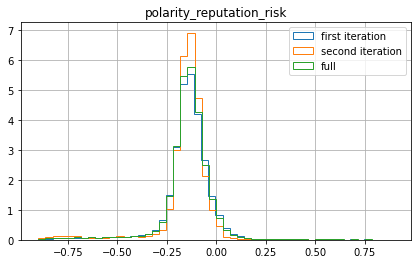

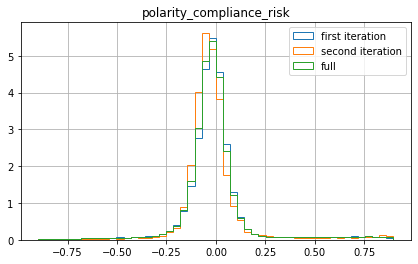

In [45]:
llama = [col for col in sent_df.columns if 'polarity' in col]

for col in llama: 
    plt.figure(figsize=(7, 4))
    plt.title(col)
    plt.hist(sent_df[~sent_df['ACC_NUM'].isin(missing['ACC_NUM'])][col], bins=50, label='first iteration', density=True, histtype='step')
    plt.hist(sent_df[sent_df['ACC_NUM'].isin(missing['ACC_NUM'])][col], bins=50, label='second iteration', density=True, histtype='step')
    plt.hist(sent_df[col], bins=50, label='full', density=True, histtype='step')
    plt.legend()
    plt.grid()
    plt.show()

In [33]:
lm_data = pd.read_csv('Loughran-McDonald_10X_Summaries_1993-2023.csv')
# lm_data['FILING_DATE'].min()

In [40]:
lm_data

,CIK,FILING_DATE,ACC_NUM,CPR,FORM_TYPE,CoName,SIC,FFInd,N_Words,N_Unique_Words,N_Negative,N_Positive,N_Uncertainty,N_Litigious,N_StrongModal,N_WeakModal,N_Constraining,N_Complexity,N_Negation,GrossFileSize,NetFileSize,NonTextDocTypeChars,HTMLChars,XBRLChars,XMLChars,N_Exhibits
0,60512,19930813,0000060512-94-000005,19930630,10-Q,LOUISIANA LAND & EXPLORATION CO,1311,30,4068,770,96,3,24,44,9,6,8,18,1,63255,43072,0,464,0,0,0
1,66740,19930813,0000066740-94-000015,19930630,10-Q,MINNESOTA MINING & MANUFACTURING CO,2670,38,4389,844,53,20,16,21,9,7,8,34,3,57283,37946,0,392,0,0,3
2,60512,19931007,0000060512-94-000006,19921231,10-K-A,LOUISIANA LAND & EXPLORATION CO,1311,30,8719,1239,207,29,74,109,31,15,32,72,5,114136,86058,0,944,0,0,0
3,60512,19931110,0000060512-94-000007,19930930,10-Q,LOUISIANA LAND & EXPLORATION CO,1311,30,4938,812,108,8,24,55,16,4,5,24,1,72062,50742,0,505,0,0,0
4,11860,19931112,0000011860-94-000005,19930930,10-Q,BETHLEHEM STEEL CORP /DE/,3312,19,3823,898,77,32,23,60,19,5,32,11,2,40392,32088,0,201,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1198489,1485029,20231229,0001096906-23-002468,20230930,10-Q,New Asia Holdings Inc.,3949,6,7571,1129,108,90,80,54,34,30,30,15,5,1391613,58631,351728,266894,295925,398901,8
1198490,1528172,20231229,0001493152-23-046444,20230930,10-Q,ENDONOVO THERAPEUTICS INC.,3845,12,8020,1158,123,35,104,50,24,15,43,48,6,5526013,64538,910730,1722467,1275827,1414929,7
1198491,1593001,20231229,0001213900-23-099837,20230930,10-Q,NightFood Holdings Inc.,2060,2,26670,2003,357,93,186,595,55,94,136,61,14,5955010,183736,1349338,1308900,1463043,1531765,9
1198492,1710495,20231229,0001493152-23-046439,20231031,10-Q,PINEAPPLE EXPRESS CANNABIS Co,7372,34,4985,841,79,15,60,35,12,15,23,14,2,1683790,40289,400454,390541,364246,451166,8


In [70]:
sent_df.tail()

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,SIC,industry_number,industry_code,industry_name,sic_code
75357,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614,0.095707,0.200253,-0.104546,0.206909,0.194901,0.012009,0.197632,0.083611,0.114021,0.155170,0.225895,-0.070724,0.157509,0.195686,-0.038177,0.136917,0.213871,-0.076954,0.119865,0.224174,-0.104309,0.179798,0.183304,-0.003506,4412,NaN,Other,Other,NaN
75358,b'317264',2018-03-31,7.49,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.62410,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628,0.249641,0.124596,0.125046,0.177704,0.198792,-0.021088,0.208191,0.088318,0.119873,0.166096,0.224041,-0.057945,0.170006,0.179379,-0.009373,0.170395,0.166519,0.003876,0.120937,0.224049,-0.103111,0.194916,0.175125,0.019791,4412,NaN,Other,Other,NaN
75359,b'317264',2019-03-31,6.42,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.17856,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530,0.196259,0.149347,0.046911,0.183228,0.181396,0.001831,0.212265,0.100769,0.111496,0.150749,0.230598,-0.079849,0.162548,0.174809,-0.012260,0.170319,0.157532,0.012787,0.106194,0.226555,-0.120361,0.178463,0.175533,0.002930,4412,NaN,Other,Other,NaN
75360,b'318728',2017-12-31,51.71,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.39863,0.891005,334320819.0,142348.0,2.348616,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623,0001527469-18-000011,1527469,20180226,0.275541,0.062815,0.212727,0.261368,0.104507,0.156860,0.217812,0.081093,0.136719,0.124924,0.248207,-0.123283,0.162182,0.163403,-0.001221,0.126629,0.193329,-0.066700,0.094791,0.220154,-0.125362,0.156227,0.183697,-0.027470,6311,11.0,Money,Finance,6311
75361,b'318728',2018-12-31,39.83,197.100,8276.000,0.722051,55804.0,16496.0,2019-02-27,b'1527469_0001527469-19-000007',7850.49300,1.054201,338861633.0,164849.0,2.055588,-0.000151,0.0,0.006164,0.007526,0.013676,-0.290089,0.077833,0.049895,0.224715,0.001628,-0.119722,-0.002462,2019.0,8.968332,-1.054262,0001527469-19-000007,1527469,20190227,0.308287,0.038329,0.269958,0.214905,0.121994,0.092911,0.194481,0.106506,0.087975,0.145149,0.238369,-0.093220,0.146938,0.192493,-0.045555,0.152397,0.171906,-0.019508,0.096382,0.239773,-0.143391,0.139240,0.200123,-0.060883,6311,11.0,Money,Finance,6311


## Growth sentiments 10-K

In [23]:
growth = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_sentiment_MB/final_results.csv')

growth = growth.rename(columns={'positive': 'positive_growth_MB',
                       'negative': 'negative_growth_MB',
                       'polarity': 'polarity_growth_MB'})

In [24]:
growth_llama = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_sentiment_llama/final_results_growth_llama.csv')

growth_llama = growth_llama.rename(columns={'positive': 'positive_growth_llama',
                                   'negative': 'negative_growth_llama',
                                   'polarity': 'polarity_growth_llama'})

In [25]:
growth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95556 entries, 0 to 95555
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               95556 non-null  int64  
 1   positive_growth_MB  95556 non-null  float64
 2   negative_growth_MB  95556 non-null  float64
 3   polarity_growth_MB  95556 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 2.9 MB


In [33]:
res_df = pd.read_csv('/home/jovyan/datavol-2/df_whole_sample.csv')
res_df.columns = ['index',  'CIK', 'FILING_DATE', 'ACC_NUM']

In [34]:
res_df['CIK'] = res_df['CIK'].astype(str)
res_df['FILING_DATE'] =res_df['FILING_DATE'].astype(str)
res_df['ACC_NUM'] = res_df['ACC_NUM'].astype(str)

In [35]:
res_df1 = res_df.merge(growth, on='index', how='inner')
res_df2 = res_df.merge(growth_llama, on='index', how='inner')

In [66]:
sent_df_growth = sent_df.merge(res_df1.drop('index', axis=1), on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='outer')
sent_df_growth.shape

(107914, 60)

In [67]:
sent_df_growth = sent_df_growth.merge(res_df2.drop('index', axis=1), on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='outer')
sent_df_growth.shape

(108836, 63)

In [68]:
sent_df_growth[['polarity_general', 'polarity_growth_MB', 'polarity_growth_llama']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 108836 entries, 0 to 108835
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   polarity_general       64774 non-null  float64
 1   polarity_growth_MB     95557 non-null  float64
 2   polarity_growth_llama  97955 non-null  float64
dtypes: float64(3)
memory usage: 3.3 MB


In [69]:
lm_data = pd.read_csv('Loughran-McDonald_10X_Summaries_1993-2023.csv',
                      usecols=['CIK', 'FILING_DATE', 'ACC_NUM', 'SIC'])
# lm_data['FILING_DATE'].min()

In [70]:
lm_data['CIK'] = lm_data['CIK'].astype(str)
lm_data['FILING_DATE'] = lm_data['FILING_DATE'].astype(str)

In [71]:
# sent_df_ = sent_df.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')

sent_df_growth = sent_df_growth.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
sent_df_growth['SIC'] = sent_df_growth['SIC'].astype(str)

In [72]:
file_path = 'Siccodes12.txt'
df_expanded = parse_industry_file_with_expanded_codes(file_path)
df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)

In [73]:
df_expanded.head()

,industry_number,industry_code,industry_name,sic_code
0,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",100
1,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",101
2,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",102
3,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",103
4,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",104


In [74]:
sent_df_growth = sent_df_growth.merge(df_expanded, left_on='SIC', right_on='sic_code', how='left')

sent_df_growth['industry_code'] = sent_df_growth['industry_code'].fillna('Other')
sent_df_growth['industry_name'] = sent_df_growth['industry_name'].fillna('Other')

In [75]:
sent_df_growth['industry_code'].value_counts()

Money    22446
BusEq    17659
Other    15592
Hlth     14551
Shops     9813
Manuf     9167
NoDur     4767
Enrgy     4391
Utils     2865
Durbl     2628
Chems     2481
Telcm     2476
Name: industry_code, dtype: int64

In [76]:
sent_df_growth[['SIC', 'industry_code']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 108836 entries, 0 to 108835
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   SIC            108836 non-null  object
 1   industry_code  108836 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB


In [48]:
sent_df_growth.to_csv("frankel_sentiments_full_sample_with_growth.tsv.gz", sep='\t', compression='gzip', index=False)

In [78]:
sent_df_growth.to_csv("10K_sentiments_with_frankel_data.tsv.gz", sep='\t', compression='gzip', index=False)

In [80]:
sent_df_growth.columns

Index(['gvkey', 'datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco',
       'permno', 'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT',
       'turnover', 'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg',
       'tone', 'tone_posharvard', 'tone_negharvard', 'tone_harvard',
       'rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'year', 'ln_mve',
       'factorpred_car01', 'ACC_NUM', 'CIK', 'FILING_DATE', 'positive_general',
       'negative_general', 'polarity_general', 'positive_revenue',
       'negative_revenue', 'polarity_revenue', 'positive_profit',
       'negative_profit', 'polarity_profit', 'positive_strategic_risk',
       'negative_strategic_risk', 'polarity_strategic_risk',
       'positive_operational_risk', 'negative_operational_risk',
       'polarity_operational_risk', 'positive_financial_risk',
       'negative_financial_risk', 'polarity_financial_risk',
       'positive_reputation_risk', 'negative_reputation_risk',
       'polarity_reputation_ris

## Growth 10 Qs

### 2003

In [6]:
growth = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_MB_10qs_2003/final_results_v0.csv')

growth = growth.rename(columns={'positive': 'positive_growth_MB_10q',
                       'negative': 'negative_growth_MB_10q',
                       'polarity': 'polarity_growth_MB_10q'})

In [8]:
growth_llama = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_llama_10qs/final_results_llama_10q_2003.csv')

growth_llama = growth_llama.rename(columns={'positive': 'positive_growth_llama_10q',
                                   'negative': 'negative_growth_llama_10q',
                                   'polarity': 'polarity_growth_llama_10q'})

In [11]:
res_df = pd.read_csv('/home/jovyan/datavol-2/res_df_10qs_2003.csv') #index=True)
res_df.columns = ['index',  'CIK', 'FILING_DATE', 'ACC_NUM']

In [13]:
res_df['CIK'] = res_df['CIK'].astype(str)
res_df['FILING_DATE'] =res_df['FILING_DATE'].astype(str)
res_df['ACC_NUM'] = res_df['ACC_NUM'].astype(str)

In [14]:
res_df1 = res_df.merge(growth, on='index', how='left')
res_df2 = res_df.merge(growth_llama, on='index', how='left')

In [29]:
res_df1 = res_df1.drop('index', axis=1)
res_df2 = res_df2.drop('index', axis=1)

In [30]:
res_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4634 entries, 0 to 4633
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CIK                     4634 non-null   object 
 1   FILING_DATE             4634 non-null   object 
 2   ACC_NUM                 4634 non-null   object 
 3   positive_growth_MB_10q  4629 non-null   float64
 4   negative_growth_MB_10q  4629 non-null   float64
 5   polarity_growth_MB_10q  4629 non-null   float64
dtypes: float64(3), object(3)
memory usage: 217.3+ KB


In [31]:
res_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4634 entries, 0 to 4633
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CIK                        4634 non-null   object 
 1   FILING_DATE                4634 non-null   object 
 2   ACC_NUM                    4634 non-null   object 
 3   positive_growth_llama_10q  4614 non-null   float64
 4   negative_growth_llama_10q  4614 non-null   float64
 5   polarity_growth_llama_10q  4614 non-null   float64
dtypes: float64(3), object(3)
memory usage: 217.3+ KB


### 2004 -- 2023

In [20]:
growth = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_MB_10qs/final_results.csv')

growth = growth.rename(columns={'positive': 'positive_growth_MB_10q',
                       'negative': 'negative_growth_MB_10q',
                       'polarity': 'polarity_growth_MB_10q'})

In [21]:
growth_llama = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_llama_10qs/results_20260320_200610_llama_10q_2004_2023.csv')

growth_llama = growth_llama.rename(columns={'positive': 'positive_growth_llama_10q',
                                   'negative': 'negative_growth_llama_10q',
                                   'polarity': 'polarity_growth_llama_10q'})

In [22]:
res_df = pd.read_csv('/home/jovyan/datavol-2/res_df_10qs_2004_2023.csv')
res_df.columns = ['index',  'CIK', 'FILING_DATE', 'ACC_NUM']

res_df['CIK'] = res_df['CIK'].astype(str)
res_df['FILING_DATE'] =res_df['FILING_DATE'].astype(str)
res_df['ACC_NUM'] = res_df['ACC_NUM'].astype(str)

In [24]:
res_df11 = res_df.merge(growth, on='index', how='left')
res_df22 = res_df.merge(growth_llama, on='index', how='left')

In [32]:
res_df11 = res_df11.drop('index', axis=1)
res_df22 = res_df22.drop('index', axis=1)

In [33]:
res_df11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191687 entries, 0 to 191686
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CIK                     191687 non-null  object 
 1   FILING_DATE             191687 non-null  object 
 2   ACC_NUM                 191687 non-null  object 
 3   positive_growth_MB_10q  191621 non-null  float64
 4   negative_growth_MB_10q  191621 non-null  float64
 5   polarity_growth_MB_10q  191621 non-null  float64
dtypes: float64(3), object(3)
memory usage: 8.8+ MB


In [34]:
res_df22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191683 entries, 0 to 191682
Data columns (total 6 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CIK                        191683 non-null  object 
 1   FILING_DATE                191683 non-null  object 
 2   ACC_NUM                    191683 non-null  object 
 3   positive_growth_llama_10q  85000 non-null   float64
 4   negative_growth_llama_10q  85000 non-null   float64
 5   polarity_growth_llama_10q  85000 non-null   float64
dtypes: float64(3), object(3)
memory usage: 8.8+ MB


In [37]:
fin_mb_10q = pd.concat([res_df1, res_df11], axis=0, ignore_index=True)
fin_llama_10q = pd.concat([res_df2, res_df22], axis=0, ignore_index=True)

In [48]:
fin_llama_10q.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196317 entries, 0 to 196316
Data columns (total 6 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CIK                        196317 non-null  object 
 1   FILING_DATE                196317 non-null  object 
 2   ACC_NUM                    196317 non-null  object 
 3   positive_growth_llama_10q  89614 non-null   float64
 4   negative_growth_llama_10q  89614 non-null   float64
 5   polarity_growth_llama_10q  89614 non-null   float64
dtypes: float64(3), object(3)
memory usage: 9.0+ MB


In [49]:
fin_mb_10q.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196321 entries, 0 to 196320
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CIK                     196321 non-null  object 
 1   FILING_DATE             196321 non-null  object 
 2   ACC_NUM                 196321 non-null  object 
 3   positive_growth_MB_10q  196250 non-null  float64
 4   negative_growth_MB_10q  196250 non-null  float64
 5   polarity_growth_MB_10q  196250 non-null  float64
dtypes: float64(3), object(3)
memory usage: 9.0+ MB


In [46]:
fin_mb_10q[~fin_mb_10q['polarity_growth_MB_10q'].isnull()]['FILING_DATE'].astype(str).str[:4].value_counts().sort_index()

FILING_DATE
2003     4629
2004     4740
2005     4925
2006     5184
2007     5568
2008     7163
2009     7567
2010     7848
2011     8298
2012     8724
2013     8999
2014     9494
2015    10009
2016    10445
2017    10846
2018    11430
2019    12144
2020    12057
2021    14738
2022    16329
2023    15113
Name: count, dtype: int64

In [47]:
fin_llama_10q[~fin_llama_10q['polarity_growth_llama_10q'].isnull()]['FILING_DATE'].astype(str).str[:4].value_counts().sort_index()

FILING_DATE
2003    4614
2004    3710
2005    3693
2006    3715
2007    3839
2008    4287
2009    4308
2010    4317
2011    4431
2012    4500
2013    4425
2014    4375
2015    4367
2016    4413
2017    4397
2018    4389
2019    4460
2020    4194
2021    4462
2022    4458
2023    4260
Name: count, dtype: int64

In [58]:
final = fin_llama_10q.merge(fin_mb_10q, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='outer')

In [59]:
final = final.drop_duplicates()

In [60]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196316 entries, 0 to 196324
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CIK                        196316 non-null  object 
 1   FILING_DATE                196316 non-null  object 
 2   ACC_NUM                    196316 non-null  object 
 3   positive_growth_llama_10q  89613 non-null   float64
 4   negative_growth_llama_10q  89613 non-null   float64
 5   polarity_growth_llama_10q  89613 non-null   float64
 6   positive_growth_MB_10q     196245 non-null  float64
 7   negative_growth_MB_10q     196245 non-null  float64
 8   polarity_growth_MB_10q     196245 non-null  float64
dtypes: float64(6), object(3)
memory usage: 15.0+ MB


In [18]:
lm_data = pd.read_csv('Loughran-McDonald_10X_Summaries_1993-2023.csv',
                      usecols=['CIK', 'FILING_DATE', 'ACC_NUM', 'SIC'])
# lm_data['FILING_DATE'].min()

In [63]:
lm_data['CIK'] = lm_data['CIK'].astype(str)
lm_data['FILING_DATE'] = lm_data['FILING_DATE'].astype(str)

In [64]:
# sent_df_ = sent_df.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')

final = final.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
final['SIC'] = final['SIC'].astype(str)

In [65]:
file_path = 'Siccodes12.txt'
df_expanded = parse_industry_file_with_expanded_codes(file_path)
df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)

In [66]:
df_expanded.head()

,industry_number,industry_code,industry_name,sic_code
0,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",100
1,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",101
2,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",102
3,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",103
4,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",104


In [67]:
final = final.merge(df_expanded, left_on='SIC', right_on='sic_code', how='left')

final['industry_code'] = final['industry_code'].fillna('Other')
final['industry_name'] = final['industry_name'].fillna('Other')

In [68]:
final['industry_code'].value_counts()

industry_code
Money    46913
Other    30712
Hlth     28699
BusEq    26446
Shops    15939
Manuf    15933
NoDur     8277
Enrgy     7122
Chems     4847
Durbl     4684
Telcm     3583
Utils     3161
Name: count, dtype: int64

In [69]:
final[['SIC', 'industry_code']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196316 entries, 0 to 196315
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   SIC            196316 non-null  object
 1   industry_code  196316 non-null  object
dtypes: object(2)
memory usage: 3.0+ MB


In [70]:
final

,CIK,FILING_DATE,ACC_NUM,positive_growth_llama_10q,negative_growth_llama_10q,polarity_growth_llama_10q,positive_growth_MB_10q,negative_growth_MB_10q,polarity_growth_MB_10q,SIC,industry_number,industry_code,industry_name,sic_code
0,1000045,20050812,0000950144-05-008668,0.454353,0.128258,0.326096,0.514082,0.270763,0.243319,6153,11.0,Money,Finance,6153
1,1000045,20051110,0000950144-05-011577,0.485023,0.109409,0.375614,0.514517,0.228523,0.285994,6153,11.0,Money,Finance,6153
2,1000045,20060214,0001144204-06-005708,0.443272,0.137440,0.305832,0.548031,0.241428,0.306602,6153,11.0,Money,Finance,6153
3,1000045,20060814,0001193125-06-172516,0.459038,0.128014,0.331024,0.436758,0.338926,0.097832,6153,11.0,Money,Finance,6153
4,1000045,20061114,0001193125-06-234357,0.433056,0.137924,0.295132,0.507121,0.247917,0.259204,6153,11.0,Money,Finance,6153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196311,9984,20220502,0000009984-22-000075,0.315418,0.104355,0.211063,0.485148,0.228722,0.256426,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490
196312,9984,20221028,0000009984-22-000167,0.259249,0.126392,0.132856,0.534070,0.250631,0.283439,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490
196313,9984,20230428,0000009984-23-000086,0.262693,0.119972,0.142721,0.560853,0.224199,0.336654,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490
196314,9984,20230731,0000009984-23-000148,0.314877,0.101055,0.213821,0.370572,0.369579,0.000993,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490


In [71]:
final.to_csv("growth_10q_llama_mb.tsv.gz", sep='\t', compression='gzip', index=False)

## Fin risk 10 Qs

### 2003

In [10]:
risk = pd.read_csv('/home/jovyan/datavol-2/sentiments/financial_risk_10qs_2003/fin_risk_2003_final.csv')

risk = risk.rename(columns={'positive': 'positive_financial_risk',
                       'negative': 'negative_financial_risk',
                       'polarity': 'polarity_financial_risk'})

In [11]:
res_df = pd.read_csv('/home/jovyan/datavol-2/res_df_10qs_2003.csv') #index=True)
res_df.columns = ['index',  'CIK', 'FILING_DATE', 'ACC_NUM']

In [12]:
res_df['CIK'] = res_df['CIK'].astype(str)
res_df['FILING_DATE'] =res_df['FILING_DATE'].astype(str)
res_df['ACC_NUM'] = res_df['ACC_NUM'].astype(str)

In [13]:
res_df1 = res_df.merge(risk, on='index', how='left')

In [14]:
res_df1 = res_df1.drop('index', axis=1)

In [15]:
res_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4634 entries, 0 to 4633
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CIK                      4634 non-null   object 
 1   FILING_DATE              4634 non-null   object 
 2   ACC_NUM                  4634 non-null   object 
 3   positive_financial_risk  4616 non-null   float64
 4   negative_financial_risk  4616 non-null   float64
 5   polarity_financial_risk  4616 non-null   float64
dtypes: float64(3), object(3)
memory usage: 217.3+ KB


### 2004 -- 2023

In [16]:
risk_part1 = pd.read_csv('/home/jovyan/datavol-2/sentiments/financial_risk_10qs/results_20260327_095438_1000_reports.csv')

risk_part1 = risk_part1.rename(columns={'positive': 'positive_financial_risk',
                       'negative': 'negative_financial_risk',
                       'polarity': 'polarity_financial_risk'})

In [17]:
risk_part2 = pd.read_csv('/home/jovyan/datavol-2/sentiments/financial_risk_10qs_part2/results_20260327_110627_500_reports.csv')

risk_part2 = risk_part2.rename(columns={'positive': 'positive_financial_risk',
                       'negative': 'negative_financial_risk',
                       'polarity': 'polarity_financial_risk'})

In [18]:
risk_part1

,index,positive_financial_risk,negative_financial_risk,polarity_financial_risk
0,0,0.200859,0.127571,0.073288
1,1,0.233521,0.114292,0.119228
2,2,0.246956,0.094292,0.152664
3,3,0.247505,0.104836,0.142670
4,4,0.227848,0.133457,0.094391
...,...,...,...,...
27995,28209,0.123440,0.230862,-0.107422
27996,28210,0.146042,0.214027,-0.067986
27997,28211,0.146542,0.200008,-0.053467
27998,28212,0.164139,0.184635,-0.020496


In [19]:
risk_part2

,index,positive_financial_risk,negative_financial_risk,polarity_financial_risk
0,44999,0.251648,0.081902,0.169746
1,45000,0.251793,0.084621,0.167171
2,45001,0.235935,0.102196,0.133739
3,45002,0.246189,0.084999,0.161190
4,45003,0.238926,0.087830,0.151096
...,...,...,...,...
28003,73166,0.252110,0.108719,0.143391
28004,73167,0.258751,0.101826,0.156925
28005,73168,0.246311,0.113163,0.133148
28006,73169,0.217751,0.141659,0.076092


In [21]:
risk = pd.concat([risk_part1, risk_part2], axis=0, ignore_index=True)

In [22]:
risk

,index,positive_financial_risk,negative_financial_risk,polarity_financial_risk
0,0,0.200859,0.127571,0.073288
1,1,0.233521,0.114292,0.119228
2,2,0.246956,0.094292,0.152664
3,3,0.247505,0.104836,0.142670
4,4,0.227848,0.133457,0.094391
...,...,...,...,...
56003,73166,0.252110,0.108719,0.143391
56004,73167,0.258751,0.101826,0.156925
56005,73168,0.246311,0.113163,0.133148
56006,73169,0.217751,0.141659,0.076092


In [23]:
res_df = pd.read_csv('/home/jovyan/datavol-2/res_df_10qs_2004_2023.csv')
res_df.columns = ['index',  'CIK', 'FILING_DATE', 'ACC_NUM']

res_df['CIK'] = res_df['CIK'].astype(str)
res_df['FILING_DATE'] =res_df['FILING_DATE'].astype(str)
res_df['ACC_NUM'] = res_df['ACC_NUM'].astype(str)

In [24]:
res_df

,index,CIK,FILING_DATE,ACC_NUM
0,0,1750,20040114,0001104659-04-000842
1,1,1750,20041001,0001104659-04-029310
2,2,1750,20050105,0001104659-05-000400
3,3,1750,20050406,0001104659-05-015316
4,4,1750,20051005,0001104659-05-047317
...,...,...,...,...
191674,191674,1980088,20231207,0001628280-23-041085
191675,191675,1981792,20231106,0001628280-23-037021
191676,191676,1983736,20231113,0001493152-23-040360
191677,191677,1984060,20231031,0000950170-23-056532


In [25]:
res_df11 = res_df.merge(risk, on='index', how='left')

In [29]:
res_df11 = res_df11.drop('index', axis=1)

In [30]:
res_df11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191689 entries, 0 to 191688
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CIK                      191689 non-null  object 
 1   FILING_DATE              191689 non-null  object 
 2   ACC_NUM                  191689 non-null  object 
 3   positive_financial_risk  56008 non-null   float64
 4   negative_financial_risk  56008 non-null   float64
 5   polarity_financial_risk  56008 non-null   float64
dtypes: float64(3), object(3)
memory usage: 8.8+ MB


In [31]:
res_df11

,CIK,FILING_DATE,ACC_NUM,positive_financial_risk,negative_financial_risk,polarity_financial_risk
0,1750,20040114,0001104659-04-000842,0.200859,0.127571,0.073288
1,1750,20041001,0001104659-04-029310,0.233521,0.114292,0.119228
2,1750,20050105,0001104659-05-000400,0.246956,0.094292,0.152664
3,1750,20050406,0001104659-05-015316,0.247505,0.104836,0.142670
4,1750,20051005,0001104659-05-047317,0.227848,0.133457,0.094391
...,...,...,...,...,...,...
191684,1980088,20231207,0001628280-23-041085,NaN,NaN,NaN
191685,1981792,20231106,0001628280-23-037021,NaN,NaN,NaN
191686,1983736,20231113,0001493152-23-040360,NaN,NaN,NaN
191687,1984060,20231031,0000950170-23-056532,NaN,NaN,NaN


In [32]:
fin_risk_10q = pd.concat([res_df1, res_df11], axis=0, ignore_index=True)

In [34]:
fin_risk_10q.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196323 entries, 0 to 196322
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CIK                      196323 non-null  object 
 1   FILING_DATE              196323 non-null  object 
 2   ACC_NUM                  196323 non-null  object 
 3   positive_financial_risk  60624 non-null   float64
 4   negative_financial_risk  60624 non-null   float64
 5   polarity_financial_risk  60624 non-null   float64
dtypes: float64(3), object(3)
memory usage: 9.0+ MB


In [36]:
fin_risk_10q[~fin_risk_10q['polarity_financial_risk'].isnull()]['FILING_DATE'].astype(str).str[:4].value_counts().sort_index()

FILING_DATE
2003    4616
2004    2496
2005    2473
2006    2478
2007    2570
2008    2835
2009    2843
2010    2834
2011    2931
2012    2964
2013    2907
2014    2883
2015    2869
2016    2895
2017    2872
2018    2860
2019    2918
2020    2737
2021    2924
2022    2917
2023    2802
Name: count, dtype: int64

In [37]:
lm_data = pd.read_csv('Loughran-McDonald_10X_Summaries_1993-2023.csv',
                      usecols=['CIK', 'FILING_DATE', 'ACC_NUM', 'SIC'])
# lm_data['FILING_DATE'].min()

In [38]:
lm_data['CIK'] = lm_data['CIK'].astype(str)
lm_data['FILING_DATE'] = lm_data['FILING_DATE'].astype(str)

In [39]:
# sent_df_ = sent_df.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')

final = fin_risk_10q.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
final['SIC'] = final['SIC'].astype(str)

In [40]:
file_path = 'Siccodes12.txt'
df_expanded = parse_industry_file_with_expanded_codes(file_path)
df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)

In [41]:
df_expanded.head()

,industry_number,industry_code,industry_name,sic_code
0,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",100
1,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",101
2,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",102
3,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",103
4,1,NoDur,"Consumer Nondurables -- Food, Tobacco, Textile...",104


In [42]:
final = final.merge(df_expanded, left_on='SIC', right_on='sic_code', how='left')

final['industry_code'] = final['industry_code'].fillna('Other')
final['industry_name'] = final['industry_name'].fillna('Other')

In [45]:
final[~final['polarity_financial_risk'].isnull()]['industry_code'].value_counts()

industry_code
Money    13194
Manuf     8158
BusEq     8051
Other     7312
Hlth      6060
Shops     5468
NoDur     3751
Enrgy     2762
Chems     2025
Durbl     1957
Utils     1033
Telcm      853
Name: count, dtype: int64

In [46]:
final[['SIC', 'industry_code']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196323 entries, 0 to 196322
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   SIC            196323 non-null  object
 1   industry_code  196323 non-null  object
dtypes: object(2)
memory usage: 3.0+ MB


In [47]:
final

,CIK,FILING_DATE,ACC_NUM,positive_financial_risk,negative_financial_risk,polarity_financial_risk,SIC,industry_number,industry_code,industry_name,sic_code
0,1750,20030113,0001047469-03-001161,0.184906,0.166996,0.017910,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720
1,1750,20030414,0001104659-03-006403,0.170876,0.184483,-0.013607,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720
2,1750,20031014,0001104659-03-022660,0.210640,0.138504,0.072136,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720
3,1800,20030515,0001047469-03-018718,0.235806,0.135082,0.100723,2834,10.0,Hlth,"Healthcare, Medical Equipment, and Drugs",2834
4,1800,20031110,0001047469-03-036636,0.231430,0.141174,0.090256,2834,10.0,Hlth,"Healthcare, Medical Equipment, and Drugs",2834
...,...,...,...,...,...,...,...,...,...,...,...
196318,1980088,20231207,0001628280-23-041085,NaN,NaN,NaN,1311,4.0,Enrgy,"Oil, Gas, and Coal Extraction and Products",1311
196319,1981792,20231106,0001628280-23-037021,NaN,NaN,NaN,6798,11.0,Money,Finance,6798
196320,1983736,20231113,0001493152-23-040360,NaN,NaN,NaN,7370,6.0,BusEq,"Business Equipment -- Computers, Software, and...",7370
196321,1984060,20231031,0000950170-23-056532,NaN,NaN,NaN,1311,4.0,Enrgy,"Oil, Gas, and Coal Extraction and Products",1311


In [48]:
final.to_csv("financial_risk_10q_llama.tsv.gz", sep='\t', compression='gzip', index=False)

----

## OLD CODE

In [32]:
llama = [col for col in sent_df.columns if 'polarity' in col]

df_ = sent_df[list(df.columns) + llama].copy()
df_

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,polarity_general,polarity_revenue,polarity_profit,polarity_strategic_risk,polarity_operational_risk,polarity_financial_risk,polarity_reputation_risk,polarity_compliance_risk
0,b'001004',2002-05-31,11.44,31.870,310.235,0.903180,20000.0,54594.0,2002-08-26,b'1750_0000912057-02-033450',364.59280,0.850908,32389900.0,26860.0,1.205879,-0.002825,0.0,-0.001721,0.004142,0.007198,-0.269461,0.055273,0.027433,0.336617,0.006738,0.008455,0.006816,2002.0,5.898781,0.604134,0000912057-02-033450,1750,20020826,-0.136895,-0.051071,0.095757,-0.215408,-0.246918,-0.155720,-0.214748,-0.121807
1,b'001004',2003-05-31,4.50,31.851,294.988,0.900913,20000.0,54594.0,2003-08-18,b'1750_0001047469-03-028005',143.32950,2.058111,21138500.0,31850.0,0.663689,-0.000024,0.0,0.144115,0.003915,0.007516,-0.315068,0.052143,0.025575,0.341840,0.002241,-0.003203,0.002330,2003.0,4.965146,0.384908,0001047469-03-028005,1750,20030818,0.145316,0.029877,0.079727,-0.060169,0.053898,0.143921,-0.107578,-0.019112
2,b'001004',2004-05-31,9.58,32.245,301.684,0.901062,20000.0,54594.0,2004-07-22,b'1750_0001047469-04-023905',308.90710,0.976617,41549083.0,32245.0,1.288543,0.000483,0.0,-0.050975,0.004134,0.007463,-0.287037,0.055412,0.026901,0.346380,0.047686,0.114837,-0.000087,2004.0,5.733041,2.809282,0001047469-04-023905,1750,20040722,0.065392,0.103439,0.109772,-0.177845,-0.212105,-0.169449,-0.204399,-0.120747
3,b'001004',2005-05-31,16.04,32.586,314.744,1.000000,20000.0,54594.0,2005-07-22,b'1750_0001104659-05-033688',522.67944,0.602174,47055900.0,32438.0,1.450641,0.001064,0.0,-0.003768,0.004717,0.007433,-0.223529,0.053891,0.024253,0.379268,0.005943,0.044268,-0.001063,2005.0,6.258968,0.715961,0001104659-05-033688,1750,20050722,0.201285,0.093811,0.105125,-0.144043,-0.167652,-0.029873,-0.159672,-0.089550
4,b'001004',2006-05-31,24.08,36.654,422.717,1.000000,20000.0,54594.0,2006-07-17,b'1750_0001104659-06-047248',882.62832,0.478930,97373000.0,36461.0,2.670607,0.001258,0.0,0.000631,0.005518,0.009995,-0.288557,0.054063,0.027553,0.324823,-0.004829,-0.014739,-0.005074,2006.0,6.782904,-0.670415,0001104659-06-047248,1750,20060717,0.188529,0.119324,0.081741,-0.065544,-0.094933,-0.012558,-0.077286,0.018616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64769,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614,-0.104546,0.012009,0.114021,-0.070724,-0.038177,-0.076954,-0.104309,-0.003506
64770,b'317264',2018-03-31,7.49,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.62410,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628,0.125046,-0.021088,0.119873,-0.057945,-0.009373,0.003876,-0.103111,0.019791
64771,b'317264',2019-03-31,6.42,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.17856,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530,0.046911,0.001831,0.111496,-0.079849,-0.012260,0.012787,-0.120361,0.002930
64772,b'318728',2017-12-31,51.71,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.39863,0.891005,3343

In [33]:
target = 'car01'
control_variables = ['mve', 'ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']
lm_tone = ['tone', 'tone_pos', 'tone_neg']
harv_tone = ['tone_harvard', 'tone_posharvard', 'tone_negharvard']
frankel_variables = ['rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'factorpred_car01']
llama = [col for col in sent_df.columns if 'polarity' in col]
len(llama)

8

In [64]:
df = pd.read_sas('replication_package_MS-ACC-20-00126/data/finaldata_10k.sas7bdat')

In [65]:
some_cols = list(set(df.columns) - set(control_variables) - set(lm_tone) - set(harv_tone) - set(frankel_variables) - set([target]) - set(['year', 'datadate', 'filename', 'date_filed', 'mve', 'gvkey']))
some_cols

['ceq', 'SHROUT', 'volume', 'permno', 'permco', 'csho', 'prcc_f']

In [282]:
table2_with_target = create_mixed_correlation_matrix_efficient(df_[[target] + lm_tone + harv_tone + frankel_variables + llama])
table2_with_target[['car01']]

,car01
car01,1.00
tone,0.00
tone_pos,-0.00
tone_neg,-0.01
tone_harvard,-0.02
tone_posharvard,0.01
tone_negharvard,0.02
rfpred_car01,0.03
svrpred_car01,0.00
sldapred_car01,0.03


In [198]:
# table2_with_target.loc['car01']

## Table 3 Panel A
We estimate Equation (1) separately for each of the following measures of SENTIMENTi,t

In [995]:
def panel_ols_fe(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    # X = add_constant(subset[x_vars])
    # y = subset[target]
    # clusters = subset[cluster_var]

    formula = f"{target} ~ C(gvkey) + C(year) + " + " + ".join(x_vars)
    
    model = smf.ols(formula=formula, data=subset)
    results = model.fit()
    
    # model = OLS(y, X).fit()
    # results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [ ]:
panel_ols_fe(df_, target, ['tone'] + control_variables, 'gvkey')

In [284]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [286]:
control_variables = ['ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']

In [288]:
results = ols_with_cluster(df_, 'car01', ['tone'] + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     23.45
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.13e-32
Time:                        09:26:34   Log-Likelihood:                 89203.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55891   BIC:                        -1.783e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.001     -1.008      0.3

## Table 3 Panel B

In [290]:
def fit_one_factor(df, sentiment_features, control_variables):
    features_res = {}
    
    for f in sentiment_features:
        results = ols_with_cluster(df, 'car01', [f] + control_variables, 'gvkey')
        features_res[f] = {}
        features_res[f]['model'] = results
        features_res[f]['coef'] = round(results.params[1], 3)
        features_res[f]['t'] = round(results.tvalues[1], 3)
        features_res[f]['r2_adj'] = round(100*results.rsquared_adj, 3)
        pval = round(results.pvalues[1], 3)
        
        features_res[f]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[f]['sgnf'] = sgnf
        
    return features_res

In [292]:
sentiment_features = lm_tone + harv_tone + frankel_variables + llama

In [119]:
# full period sample (75k)

# table3_res = fit_one_factor(df, sentiment_features, control_variables)

# table3 = pd.DataFrame(table3_res).T.drop('model', axis=1)
# table3['coef'] = table3['coef'].astype(str) + table3['sgnf']
# table3[['coef', 't', 'r2_adj']]

,coef,t,r2_adj
tone,0.001,1.123,0.459
tone_pos,-0.16,-1.08,0.459
tone_neg,-0.05,-0.979,0.458
tone_harvard,-0.005***,-3.035,0.468
tone_posharvard,-0.01,-0.442,0.457
tone_negharvard,0.051***,2.607,0.465
rfpred_car01,0.069***,3.944,0.495
svrpred_car01,0.006,1.446,0.462
sldapred_car01,0.147***,4.324,0.487
factorpred_car01,0.001***,3.52,0.484


In [354]:
df_96_08 = df_[df_['FILING_DATE'].str[:4] <= '2008'].copy().reset_index(drop=True)
# df_96_08['FILING_DATE'].str[:4].value_counts().sort_index()

In [356]:
df_08_19 = df_[df_['FILING_DATE'].str[:4] > '2008'].copy().reset_index(drop=True)
# df_08_19['FILING_DATE'].str[:4].value_counts().sort_index()

In [366]:
table3_lm = fit_one_factor(df[df['FILING_DATE'].str[:4] <= '2008'], lm_tone, control_variables)

table3_period_lm = pd.DataFrame(table3_lm).T.drop('model', axis=1)
table3_period_lm['coef'] = table3_period_lm['coef'].astype(str) + table3_period_lm['sgnf']
# table3_period_lm[['coef', 't', 'r2_adj', 'pval']]

In [380]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [979]:
tone_res2 = {}

for tone in ['tone', 'rfpred_car01', 'polarity_general', 'polarity_revenue', 'polarity_financial_risk']:
    tone_year = []
    r2_year = []
    
    for year in range(1996, 2020):
        df_period = df_[df_['FILING_DATE'].str[:4] == str(year)].copy().reset_index(drop=True)
        res_period = fit_one_factor(df_period, [tone], control_variables)
        
        tone_year.append(res_period[tone]['t'])
        r2_year.append(res_period[tone]['r2_adj'])
        
    tone_res2[tone] = {}
    tone_res2[tone]['t'] = np.abs(np.array(tone_year))
    tone_res2[tone]['r2_adj'] = np.array(r2_year)

In [961]:
res_period['polarity_financial_risk']['r2_adj']

0.078

In [955]:
res_period = fit_one_factor(df_period, [tone], control_variables)

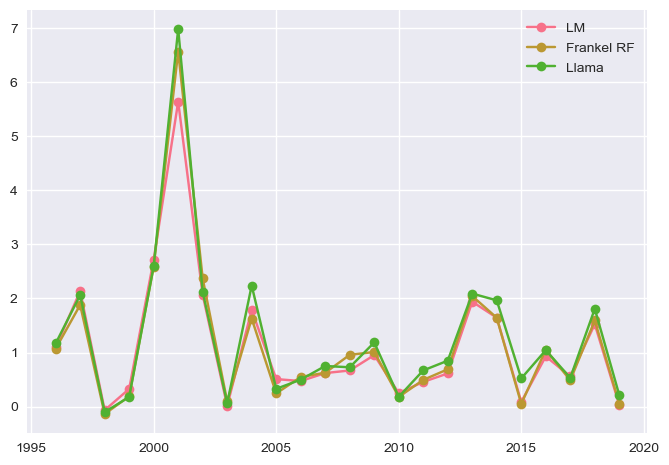

In [985]:
plt.figure()
plt.plot(range(1996, 2020), tone_res2['tone']['r2_adj'], marker='o', label='LM')
plt.plot(range(1996, 2020), tone_res2['rfpred_car01']['r2_adj'], marker='o', label='Frankel RF')
plt.plot(range(1996, 2020), tone_res2['polarity_general']['r2_adj'], marker='o', label='Llama')        
# plt.plot(range(1996, 2020), tone_res['polarity_financial_risk'], marker='o', label='Llama financial risk')
plt.legend()
plt.show()
# tone_res2['tone']['r2_adj']

In [981]:
tone_res2

{'tone': {'t': array([0.553, 2.449, 1.256, 1.662, 1.708, 1.258, 1.61 , 0.405, 2.209,
         2.884, 1.045, 0.592, 2.695, 1.39 , 1.405, 0.723, 0.023, 1.485,
         0.421, 1.529, 0.239, 1.366, 0.016, 0.017]),
  'r2_adj': array([ 1.095,  2.135, -0.066,  0.327,  2.715,  5.637,  2.065,  0.014,
          1.787,  0.509,  0.472,  0.62 ,  0.668,  0.952,  0.25 ,  0.457,
          0.613,  1.939,  1.643,  0.087,  0.929,  0.558,  1.523,  0.031])},
 'rfpred_car01': {'t': array([0.005, 1.292, 0.297, 0.445, 0.373, 4.112, 2.63 , 1.248, 0.662,
         0.129, 1.342, 0.461, 2.952, 1.629, 0.058, 0.953, 0.998, 1.305,
         0.288, 0.712, 1.199, 0.041, 0.869, 0.579]),
  'r2_adj': array([ 1.069,  1.88 , -0.137,  0.191,  2.587,  6.562,  2.369,  0.097,
          1.627,  0.243,  0.548,  0.626,  0.957,  1.01 ,  0.179,  0.494,
          0.69 ,  2.043,  1.642,  0.05 ,  1.051,  0.486,  1.592,  0.057])},
 'polarity_general': {'t': array([0.893, 2.039, 0.87 , 0.101, 0.539, 5.1  , 1.727, 1.147, 3.599,
         1.

In [382]:
table3_period_other = fit_one_factor(df_96_08, harv_tone + frankel_variables + llama, control_variables)

table3_period_other = pd.DataFrame(table3_period_other).T.drop('model', axis=1)
table3_period_other['coef'] = table3_period_other['coef'].astype(str) + table3_period_other['sgnf']

table3_period = pd.concat([table3_period_lm[['coef', 't', 'r2_adj', 'pval']],
                           table3_period_other[['coef', 't', 'r2_adj', 'pval']]
                          ], axis=0)
print(color.BOLD + 'Early sample period (1996-2008)' + color.END)
table3_period

Early sample period (1996-2008)


,coef,t,r2_adj,pval
tone,0.003***,2.61,0.79,0.009
tone_pos,-0.371**,-2.112,0.785,0.035
tone_neg,-0.237***,-3.443,0.803,0.001
tone_harvard,-0.0,-0.032,0.694,0.974
tone_posharvard,-0.03,-0.838,0.696,0.402
tone_negharvard,-0.018,-0.424,0.695,0.672
rfpred_car01,0.104***,3.579,0.766,0.0
svrpred_car01,0.007,1.18,0.701,0.238
sldapred_car01,0.126**,2.244,0.717,0.025
factorpred_car01,0.001***,2.58,0.727,0.01


In [384]:
table3_period_res = fit_one_factor(df_08_19, sentiment_features, control_variables)

table3_period = pd.DataFrame(table3_period_res).T.drop('model', axis=1)
table3_period['coef'] = table3_period['coef'].astype(str) + table3_period['sgnf']
print(color.BOLD + 'Extra sample period (2009-2019)' + color.END)
table3_period[['coef', 't', 'r2_adj', 'pval']]

Extra sample period (2009-2019)


,coef,t,r2_adj,pval
tone,-0.004,-1.538,0.337,0.124
tone_pos,0.008,0.027,0.329,0.978
tone_neg,0.166,1.635,0.338,0.102
tone_harvard,-0.007***,-2.586,0.351,0.01
tone_posharvard,-0.035,-0.782,0.331,0.434
tone_negharvard,0.069**,2.112,0.342,0.035
rfpred_car01,0.028,1.025,0.336,0.305
svrpred_car01,0.001,0.212,0.329,0.832
sldapred_car01,0.079,1.369,0.337,0.171
factorpred_car01,0.0,1.026,0.336,0.305


In [386]:
table3_period_res = fit_one_factor(df_, sentiment_features, control_variables)

table3_period = pd.DataFrame(table3_period_res).T.drop('model', axis=1)
table3_period['coef'] = table3_period['coef'].astype(str) + table3_period['sgnf']
print(color.BOLD + 'Full sample period (1996-2019)' + color.END)
table3_period[['coef', 't', 'r2_adj', 'pval']]

Full sample period (1996-2019)


,coef,t,r2_adj,pval
tone,0.001,0.584,0.421,0.559
tone_pos,-0.136,-0.778,0.421,0.437
tone_neg,-0.012,-0.194,0.42,0.847
tone_harvard,-0.005***,-2.802,0.433,0.005
tone_posharvard,-0.011,-0.406,0.42,0.685
tone_negharvard,0.056**,2.51,0.43,0.012
rfpred_car01,0.064***,3.158,0.454,0.002
svrpred_car01,0.004,0.843,0.422,0.399
sldapred_car01,0.134***,3.407,0.445,0.001
factorpred_car01,0.001***,2.822,0.444,0.005


## Multivariate regressions

In [445]:
sentiment_features

['tone',
 'tone_pos',
 'tone_neg',
 'tone_harvard',
 'tone_posharvard',
 'tone_negharvard',
 'rfpred_car01',
 'svrpred_car01',
 'sldapred_car01',
 'factorpred_car01',
 'polarity_general',
 'polarity_revenue',
 'polarity_profit',
 'polarity_strategic_risk',
 'polarity_operational_risk',
 'polarity_financial_risk',
 'polarity_reputation_risk',
 'polarity_compliance_risk']

In [456]:
results = ols_with_cluster(df_, 'car01', lm_tone + frankel_variables + llama + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     13.32
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.12e-46
Time:                        14:26:46   Log-Likelihood:                 89278.
No. Observations:               55899   AIC:                        -1.785e+05
Df Residuals:                   55877   BIC:                        -1.783e+05
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [709]:
# lm_tone + harv_tone + frankel_variables + llama
results = ols_with_cluster(df_, 'car01', lm_tone + control_variables, 'gvkey')
# print(color.BOLD + 'LM')
print('LM')
print(results.summary())

LM
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     19.52
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.27e-33
Time:                        14:54:47   Log-Likelihood:                 89208.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55889   BIC:                        -1.783e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0027      0.002      1.435      

In [653]:
# print('LM RMSE', round(np.sqrt(results.mse_resid), 5))

X = add_constant(df_[lm_tone + control_variables])
y_pred = results.predict(X)

lm_dict = {}
lm_dict['rmse'] = np.sqrt(results.mse_resid)
lm_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
lm_dict['r2_adj'] = results.rsquared_adj
lm_dict
                         
# print('LM RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('LM MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('LM R2', round(results.rsquared_adj, 4))

{'rmse': 0.04905884158643665,
 'mae': 0.17900772052741823,
 'r2_adj': 0.004348924996459669}

In [711]:
results_fr = ols_with_cluster(df_, 'car01', frankel_variables + control_variables, 'gvkey')
print('Frankel')
print(results_fr.summary())

Frankel
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     18.36
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.05e-33
Time:                        14:54:59   Log-Likelihood:                 89217.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55888   BIC:                        -1.783e+05
Df Model:                          10                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0011     

In [657]:
print('Frankel RMSE', round(np.sqrt(results_fr.mse_resid), 5))

X = add_constant(df_[frankel_variables + control_variables])
y_pred = results_fr.predict(X)
# print('Frankel RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('Frankel MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('Frankel R2', round(results_fr.rsquared_adj, 4))

fr_dict = {}
fr_dict['rmse'] = np.sqrt(results_fr.mse_resid)
fr_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
fr_dict['r2_adj'] = results_fr.rsquared_adj
fr_dict

Frankel RMSE 0.04905


{'rmse': 0.04905156593933803,
 'mae': 0.1789713154635392,
 'r2_adj': 0.004644222172728307}

In [746]:
llama = ['polarity_general',
 'polarity_revenue',
 'polarity_profit',
 'polarity_strategic_risk',
 'polarity_operational_risk',
 'polarity_financial_risk',
 'polarity_reputation_risk',
 'polarity_compliance_risk']

# llama = ['polarity_general', 'polarity_profit', 'polarity_financial_risk',]

In [748]:
results_llama = ols_with_cluster(df_, 'car01', llama + control_variables, 'gvkey')
print('Llama')
print(results_llama.summary())

Llama
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     18.07
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.77e-45
Time:                        16:23:16   Log-Likelihood:                 89265.
No. Observations:               55899   AIC:                        -1.785e+05
Df Residuals:                   55884   BIC:                        -1.784e+05
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const           

In [750]:
# print('Llama RMSE', round(np.sqrt(results_llama.mse_resid), 6))

X = add_constant(df_[llama + control_variables])
y_pred = results_llama.predict(X)
# print('Llama RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('Llama MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('Llama R2', round(results_llama.rsquared_adj, 4))

llama_dict = {}
llama_dict['rmse'] = np.sqrt(mean_squared_error(df_['car01'], y_pred))
llama_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
llama_dict['r2_adj'] = results_llama.rsquared_adj
llama_dict

{'rmse': 0.04900522712386684,
 'mae': 0.1789388649652172,
 'r2_adj': 0.006257288975319519}

In [752]:
lm_df = pd.DataFrame.from_dict(lm_dict, orient='index')
lm_df.columns = ['LM']

fr_df = pd.DataFrame.from_dict(fr_dict, orient='index')
fr_df.columns = ['Frankel']

llama_df = pd.DataFrame.from_dict(llama_dict, orient='index')
llama_df.columns = ['Llama']

res_df = pd.concat([lm_df, fr_df, llama_df], axis=1)
round(res_df, 4)

,LM,Frankel,Llama
rmse,0.0491,0.0491,0.0490
mae,0.1790,0.1790,0.1789
r2_adj,0.0043,0.0046,0.0063


### Without control

In [770]:
results = ols_with_cluster(df_, 'car01', lm_tone, 'gvkey')
# print(color.BOLD + 'LM')
print('LM')
print(results.summary())

LM
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.719
Date:                Tue, 21 Oct 2025   Prob (F-statistic):            0.00271
Time:                        16:25:09   Log-Likelihood:                 89088.
No. Observations:               55899   AIC:                        -1.782e+05
Df Residuals:                   55895   BIC:                        -1.781e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0037      0.002      2.400      

In [772]:
X = add_constant(df_[lm_tone])
y_pred = results.predict(X)

lm_dict2 = {}
lm_dict2['rmse'] = np.sqrt(results.mse_resid)
lm_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
lm_dict2['r2_adj'] = results.rsquared_adj
# lm_dict2

In [774]:
results_fr = ols_with_cluster(df_, 'car01', frankel_variables, 'gvkey')
print('Frankel')
print(results_fr.summary())

Frankel
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.37
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.37e-09
Time:                        16:25:16   Log-Likelihood:                 89116.
No. Observations:               55899   AIC:                        -1.782e+05
Df Residuals:                   55894   BIC:                        -1.782e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0007     

In [776]:
X = add_constant(df_[frankel_variables])
y_pred = results_fr.predict(X)
fr_dict2 = {}
fr_dict2['rmse'] = np.sqrt(results_fr.mse_resid)
fr_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
fr_dict2['r2_adj'] = results_fr.rsquared_adj
fr_dict2

{'rmse': 0.049138229412405136,
 'mae': 0.17906464890022694,
 'r2_adj': 0.0011239598033245812}

In [778]:
llama = ['polarity_general', 'polarity_profit', 'polarity_financial_risk',]

results_llama = ols_with_cluster(df_, 'car01', llama, 'gvkey')
print('Llama')
print(results_llama.summary())

Llama
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     53.16
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           4.92e-34
Time:                        16:25:21   Log-Likelihood:                 89192.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55895   BIC:                        -1.783e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const               

In [780]:
X = add_constant(df_[llama])
y_pred = results_llama.predict(X)

llama_dict2 = {}
llama_dict2['rmse'] = np.sqrt(mean_squared_error(df_['car01'], y_pred))
llama_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
llama_dict2['r2_adj'] = results_llama.rsquared_adj
llama_dict2

{'rmse': 0.049068739149443694,
 'mae': 0.17898868362969753,
 'r2_adj': 0.003875861344565412}

In [782]:
# without control
lm_df2 = pd.DataFrame.from_dict(lm_dict2, orient='index')
lm_df2.columns = ['LM']

fr_df2 = pd.DataFrame.from_dict(fr_dict2, orient='index')
fr_df2.columns = ['Frankel']

llama_df2 = pd.DataFrame.from_dict(llama_dict2, orient='index')
llama_df2.columns = ['Llama']

res_df2 = pd.concat([lm_df2, fr_df2, llama_df2], axis=1)
round(res_df2, 4)

,LM,Frankel,Llama
rmse,0.0492,0.0491,0.0491
mae,0.1791,0.1791,0.1790
r2_adj,0.0002,0.0011,0.0039


In [768]:
# with control
round(res_df, 4)

,LM,Frankel,Llama
rmse,0.0491,0.0491,0.0490
mae,0.1790,0.1790,0.1789
r2_adj,0.0043,0.0046,0.0063


In [ ]:
# fixed effects 
subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)

## Figure 1
Filing Returns and Sentiment

In [308]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_financial_risk', 'polarity_revenue']

for f in quantile_feats:
    df_[f'{f}_quintile'] = pd.qcut(df_[f], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')

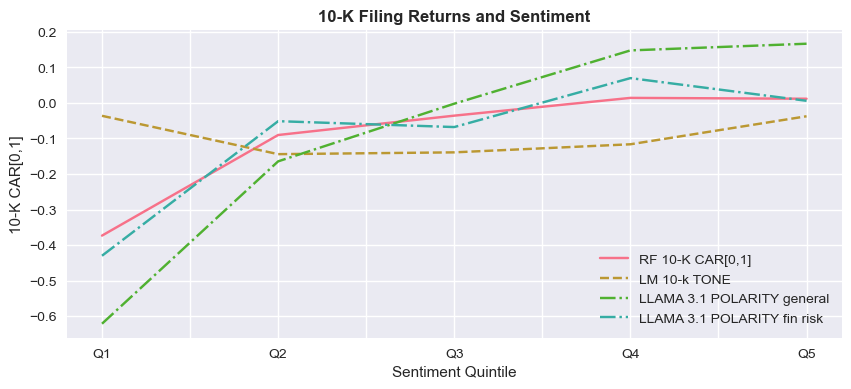

In [310]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
(100*df_.groupby(['polarity_financial_risk_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY fin risk', style='-.')
# (100*df_.groupby(['polarity_revenue_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY revenue', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.legend();

In [312]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_financial_risk', 'polarity_revenue']

for f in quantile_feats:
    df_[f'{f}_quintile'] = pd.qcut(df_[f], q=10,  duplicates='drop')

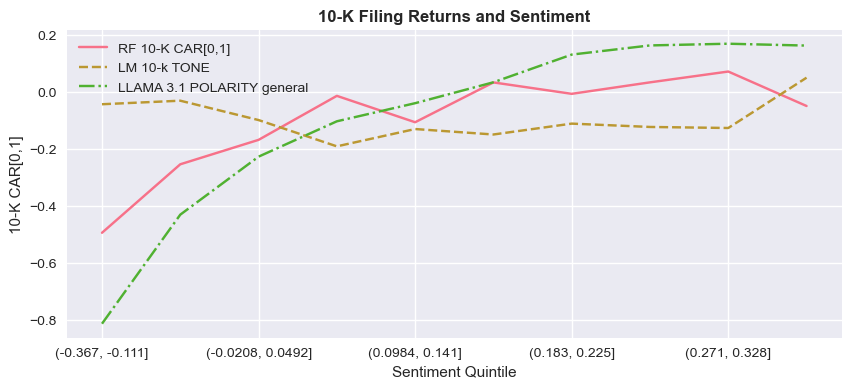

In [316]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
# (100*df_.groupby(['polarity_financial_risk_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY fin risk', style='-.')
# (100*df_.groupby(['polarity_revenue_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY revenue', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.legend();

In [388]:
df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,0.550284,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1.181769,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,0.657306,0.000424,0.0,0.025747,0.005877,0.003495,0.287129,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,0.939015,-0.000434,0.0,0.014496,0.005442,0.003495,0.287129,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,0.958469,-0.002255,0.0,-0.027259,0.004120,0.003495,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.886750,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.624100,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628
75359,b'317264',2019-03-31,6.420000,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.178560,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530
75360,b'318728',2017-12-31,51.710000,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.398630,0.891005,334320819.0,142348.0,2.348616,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623,0001527469-18-000011,1527469,20180226


In [390]:
df.columns

Index(['gvkey', 'datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco',
       'permno', 'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT',
       'turnover', 'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg',
       'tone', 'tone_posharvard', 'tone_negharvard', 'tone_harvard',
       'rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'year', 'ln_mve',
       'factorpred_car01', 'ACC_NUM', 'CIK', 'FILING_DATE'],
      dtype='object')

In [800]:
df_[['polarity_general', 'year']]

,polarity_general,year
0,-0.136895,2002.0
1,0.145316,2003.0
2,0.065392,2004.0
3,0.201285,2005.0
4,0.188529,2006.0
...,...,...
55894,-0.104546,2017.0
55895,0.125046,2018.0
55896,0.046911,2019.0
55897,0.212727,2018.0


In [ ]:
df_.groupby('year').agg({'polarity_general': 'mean'}